# Notebook 03 -- Modeling

**Data source:** `data/processed/` (parquet files from notebook 02)  
**Output:** `models/artifacts/` (serialized model files)  

**Steps:**
1. Load processed data and metadata
2. Baseline model -- Logistic Regression
3. Random Forest
4. Per-class evaluation -- precision, recall, F1
5. Cross-validation comparison
6. Save model artifacts for notebook 04 and Streamlit app

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize
import joblib
import json
import os
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CLASS_COLORS = {
    'Dropout':  '#378ADD',
    'Enrolled': '#D85A30',
    'Graduate': '#639922'
}
CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']

os.makedirs('../models/artifacts', exist_ok=True)

## 1. Load processed data and metadata

In [2]:
X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_test  = pd.read_parquet('../data/processed/X_test.parquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet').squeeze()
y_test  = pd.read_parquet('../data/processed/y_test.parquet').squeeze()

with open('../data/processed/meta.json') as f:
    meta = json.load(f)

classes = meta['classes']  # ['Dropout', 'Enrolled', 'Graduate']
class_weight_dict = {int(k): v for k, v in meta['class_weight_dict'].items()}

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {classes}")
print(f"Class weights: {class_weight_dict}")

X_train: (3539, 37)
X_test:  (885, 37)
Classes: ['Dropout', 'Enrolled', 'Graduate']
Class weights: {0: 1.0375256523013778, 1: 1.857742782152231, 2: 0.6676098849273722}


## 2. Baseline -- Logistic Regression

Logistic Regression serves as the interpretable baseline. Simple, fast, and gives us a floor to beat.
Using `class_weight='balanced'` to address class imbalance.

In [3]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)

print("Logistic Regression -- Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=classes))

Logistic Regression -- Classification Report
              precision    recall  f1-score   support

     Dropout       0.84      0.70      0.77       284
    Enrolled       0.42      0.64      0.51       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.73      0.75       885



## 3. Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)

print("Random Forest -- Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=classes))

Random Forest -- Classification Report
              precision    recall  f1-score   support

     Dropout       0.82      0.77      0.79       284
    Enrolled       0.54      0.36      0.44       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



## 4. Confusion matrices

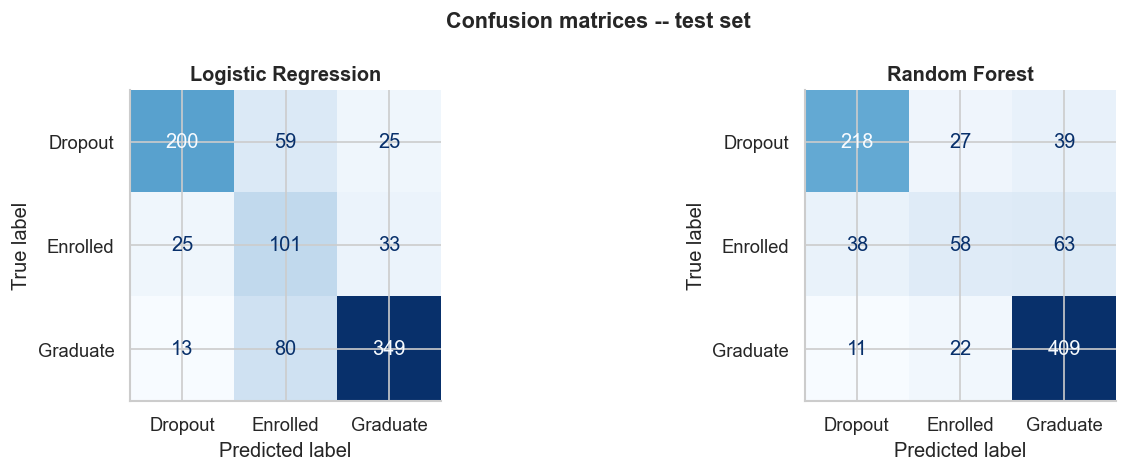

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion matrices -- test set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/modeling_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 5. Per-class F1 comparison

Per-class F1 scores:
   Class  Logistic Regression  Random Forest
 Dropout             0.766284       0.791289
Enrolled             0.506266       0.436090
Graduate             0.822144       0.858342

Macro F1 -- Logistic Regression: 0.6982
Macro F1 -- Random Forest:        0.6952


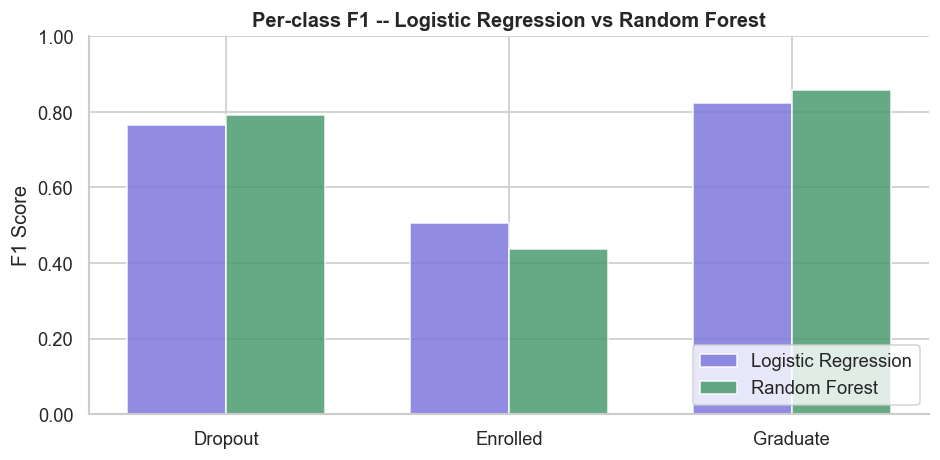

In [6]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr, average=None)
f1_rf = f1_score(y_test, y_pred_rf, average=None)

f1_df = pd.DataFrame({
    'Class': classes,
    'Logistic Regression': f1_lr,
    'Random Forest': f1_rf
})

print("Per-class F1 scores:")
print(f1_df.to_string(index=False))
print(f"\nMacro F1 -- Logistic Regression: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"Macro F1 -- Random Forest:        {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

# Plot
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, f1_lr, width, label='Logistic Regression', color='#7F77DD', alpha=0.85)
ax.bar(x + width/2, f1_rf, width, label='Random Forest', color='#4A9B6F', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_title('Per-class F1 -- Logistic Regression vs Random Forest', fontweight='bold')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('../data/modeling_f1_comparison.png', bbox_inches='tight')
plt.show()

## 6. Cross-validation comparison

5-fold stratified cross-validation on the full dataset.
Gives a more stable estimate of generalization than a single train/test split.

5-fold stratified cross-validation -- macro F1
Logistic Regression: 0.7064 (+/- 0.0121)
Random Forest:       0.6938 (+/- 0.0086)


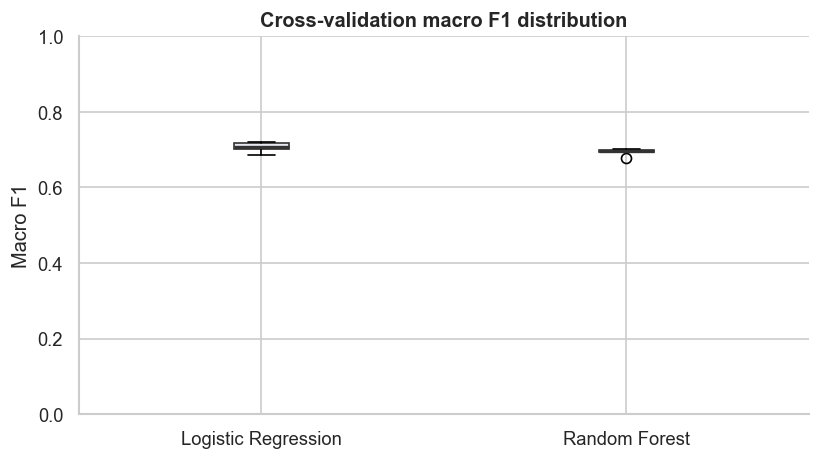

In [7]:
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_lr = cross_val_score(lr, X_full, y_full, cv=cv, scoring='f1_macro', n_jobs=-1)
cv_rf = cross_val_score(rf, X_full, y_full, cv=cv, scoring='f1_macro', n_jobs=-1)

print("5-fold stratified cross-validation -- macro F1")
print("=" * 50)
print(f"Logistic Regression: {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")
print(f"Random Forest:       {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

# Plot CV distributions
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [cv_lr, cv_rf],
    labels=['Logistic Regression', 'Random Forest'],
    patch_artist=True,
    boxprops=dict(facecolor='#E8E8F0', color='#333'),
    medianprops=dict(color='#333', linewidth=2)
)
ax.set_ylabel('Macro F1')
ax.set_title('Cross-validation macro F1 distribution', fontweight='bold')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../data/modeling_cv_comparison.png', bbox_inches='tight')
plt.show()

## 7. ROC AUC (one-vs-rest)

Macro ROC AUC (one-vs-rest):
  Logistic Regression: 0.8765
  Random Forest:       0.8876


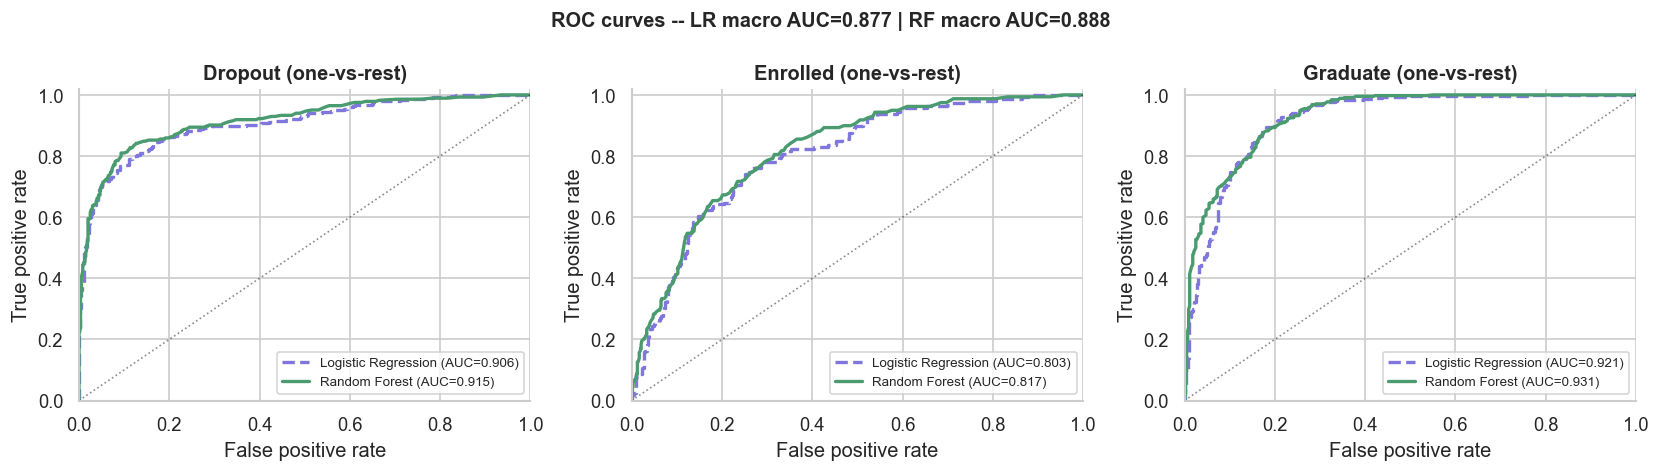

In [12]:
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

auc_lr = roc_auc_score(y_test_bin, y_proba_lr, multi_class='ovr', average='macro')
auc_rf = roc_auc_score(y_test_bin, y_proba_rf, multi_class='ovr', average='macro')

print("Macro ROC AUC (one-vs-rest):")
print(f"  Logistic Regression: {auc_lr:.4f}")
print(f"  Random Forest:       {auc_rf:.4f}")

# Plot ROC curves -- one subplot per class, both models overlaid
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

linestyles = {
    'Logistic Regression': ('--', '#7F77DD'),
    'Random Forest':       ('-',  '#4A9B6F')
}

for i, cls in enumerate(classes):
    for model_name, (y_proba, _) in [
        ('Logistic Regression', (y_proba_lr, None)),
        ('Random Forest',       (y_proba_rf, None))
    ]:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ls, color = linestyles[model_name]
        axes[i].plot(
            fpr, tpr,
            linestyle=ls,
            color=color,
            linewidth=2,
            label=f'{model_name} (AUC={roc_auc:.3f})'
        )

    # Diagonal reference line
    axes[i].plot([0, 1], [0, 1], 'k:', linewidth=1, alpha=0.5)
    axes[i].set_title(f'{cls} (one-vs-rest)', fontweight='bold')
    axes[i].set_xlabel('False positive rate')
    axes[i].set_ylabel('True positive rate')
    axes[i].legend(loc='lower right', fontsize=8)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])

plt.suptitle(
    f'ROC curves -- LR macro AUC={auc_lr:.3f} | RF macro AUC={auc_rf:.3f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/modeling_roc_curves.png', bbox_inches='tight')
plt.show()

## 8. Feature importance -- Random Forest

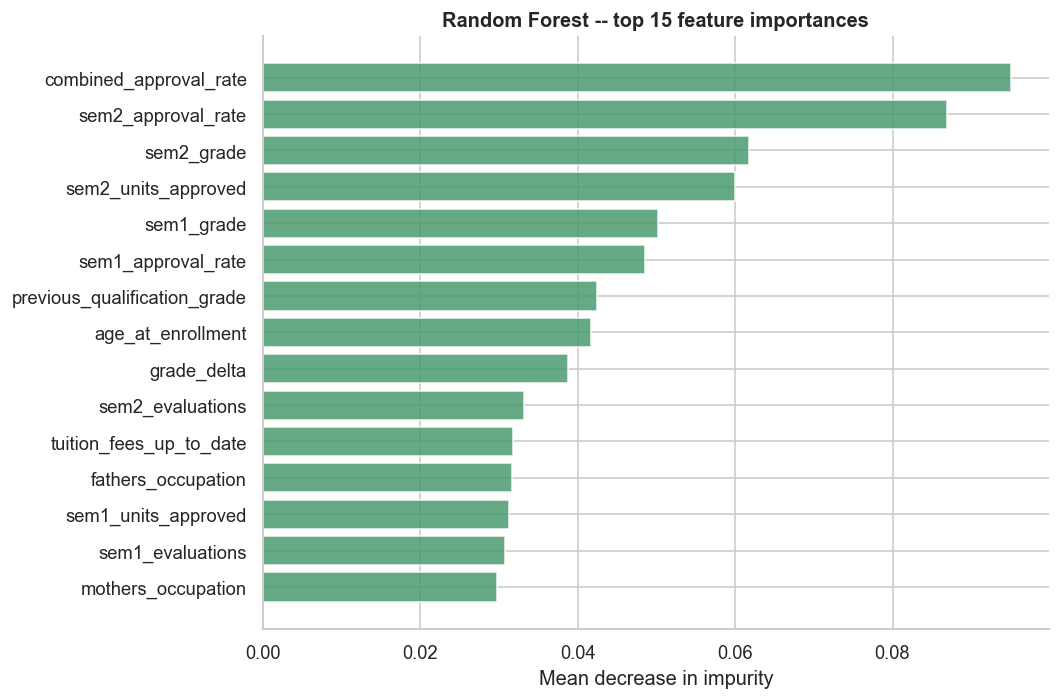


Top 15 features:
                     feature  importance
      combined_approval_rate    0.095098
          sem2_approval_rate    0.086932
                  sem2_grade    0.061823
         sem2_units_approved    0.060033
                  sem1_grade    0.050248
          sem1_approval_rate    0.048563
previous_qualification_grade    0.042470
           age_at_enrollment    0.041678
                 grade_delta    0.038782
            sem2_evaluations    0.033209
     tuition_fees_up_to_date    0.031776
          fathers_occupation    0.031709
         sem1_units_approved    0.031339
            sem1_evaluations    0.030774
          mothers_occupation    0.029745


In [9]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color='#4A9B6F',
    alpha=0.85
)
ax.set_xlabel('Mean decrease in impurity')
ax.set_title('Random Forest -- top 15 feature importances', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/modeling_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 15 features:")
print(importance_df[::-1].to_string(index=False))

## 9. Save model artifacts

In [11]:
joblib.dump(lr, '../models/artifacts/logistic_regression.pkl')
joblib.dump(rf, '../models/artifacts/random_forest.pkl')

# Save test set predictions for McNemar's test in notebook 04
predictions = pd.DataFrame({
    'y_test':    y_test.values,
    'y_pred_lr': y_pred_lr,
    'y_pred_rf': y_pred_rf
})
predictions.to_parquet('../data/processed/test_predictions.parquet', index=False)

print("Saved:")
print("  models/artifacts/logistic_regression.pkl")
print("  models/artifacts/random_forest.pkl")
print("  data/processed/test_predictions.parquet")
print(f"\nTest predictions shape: {predictions.shape}")

Saved:
  models/artifacts/logistic_regression.pkl
  models/artifacts/random_forest.pkl
  data/processed/test_predictions.parquet

Test predictions shape: (885, 3)
